Гипотеза 5: Ансамблирование моделей

Цель: ансамблировать модели (catboost и ligftGBM)

In [13]:
import pandas as pd
import re
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder

In [18]:
df_train = pd.read_csv('train_final_processed.csv')
df_test = pd.read_csv('test_final_processed.csv')
print(f"Размер тренировочных данных: {df_train.shape}")
print(f"Размер тестовых данных: {df_test.shape}")

Размер тренировочных данных: (307511, 571)
Размер тестовых данных: (48744, 570)


In [19]:
X_train_full = df_train.drop(['sk_id_curr', 'target'], axis=1)
y_train_full = df_train['target']

In [20]:
if y_train_full.dtype == 'object' or len(y_train_full.unique()) > 2:
    y_train_full = y_train_full.map({'0': 0, '1': 1}).fillna(0).astype(int)

In [21]:
common_cols = X_train_full.columns.intersection(df_test.drop(['sk_id_curr'], axis=1).columns)
if len(common_cols) < 10:
    print("Предупреждение")
X_train_full = X_train_full[common_cols]
df_test_processed = df_test[common_cols]

In [22]:
cat_cols = [col for col in common_cols if X_train_full[col].dtype == 'object']
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train_full[col] = X_train_full[col].astype(str).fillna('missing')
    df_test_processed[col] = df_test_processed[col].astype(str).fillna('missing')
    
    all_values = pd.concat([X_train_full[col], df_test_processed[col]], axis=0).unique()
    le.fit(all_values) 
    
    X_train_full[col] = le.transform(X_train_full[col])
    df_test_processed[col] = le.transform(df_test_processed[col])

C:\Users\klmv0\AppData\Local\Temp\ipykernel_20584\1254183696.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_processed[col] = df_test_processed[col].astype(str).fillna('missing')
C:\Users\klmv0\AppData\Local\Temp\ipykernel_20584\1254183696.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_processed[col] = le.transform(df_test_processed[col])
C:\Users\klmv0\AppData\Local\Temp\ipykernel_20584\1254183696.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from

In [23]:
for col in X_train_full.columns:
    X_train_full[col] = pd.to_numeric(X_train_full[col], errors='coerce')
    df_test_processed[col] = pd.to_numeric(df_test_processed[col], errors='coerce')

for col in X_train_full.columns:
    if X_train_full[col].dtype in ['float64', 'int64']:
        X_train_full[col].fillna(X_train_full[col].median(), inplace=True)
        df_test_processed[col].fillna(X_train_full[col].median(), inplace=True)

C:\Users\klmv0\AppData\Local\Temp\ipykernel_20584\1661528756.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_processed[col] = pd.to_numeric(df_test_processed[col], errors='coerce')
C:\Users\klmv0\AppData\Local\Temp\ipykernel_20584\1661528756.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_processed[col].fillna(X_train_full[col].median(), inplace=True)
C:\Users\klmv0\AppData\Local\Temp\ipykernel_20584\1661528756.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documenta

In [24]:
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)

In [25]:
cat_model_optimal = CatBoostClassifier(
    iterations=1000,     
    learning_rate=0.03,       
    depth=7,          
    auto_class_weights='SqrtBalanced',
    random_state=42,
    l2_leaf_reg=2,  
    eval_metric='AUC',
    loss_function='Logloss',
    verbose=100)

cat_model_optimal.fit(X_train, y_train, eval_set=(X_val, y_val), cat_features=cat_cols)
cat_pred_val = cat_model_optimal.predict_proba(X_val)[:, 1]
cat_pred_test = cat_model_optimal.predict_proba(df_test_processed)[:, 1]

0:	test: 0.7049538	best: 0.7049538 (0)	total: 5.24s	remaining: 1h 27m 16s
100:	test: 0.7635859	best: 0.7635859 (100)	total: 2m 1s	remaining: 17m 57s
200:	test: 0.7741216	best: 0.7741216 (200)	total: 3m 42s	remaining: 14m 45s
300:	test: 0.7784391	best: 0.7784391 (300)	total: 5m 50s	remaining: 13m 34s
400:	test: 0.7810073	best: 0.7810073 (400)	total: 7m 28s	remaining: 11m 10s
500:	test: 0.7837016	best: 0.7837016 (500)	total: 9m 6s	remaining: 9m 4s
600:	test: 0.7854420	best: 0.7854420 (600)	total: 10m 48s	remaining: 7m 10s
700:	test: 0.7863117	best: 0.7863400 (694)	total: 12m 34s	remaining: 5m 22s
800:	test: 0.7870540	best: 0.7870808 (795)	total: 14m 16s	remaining: 3m 32s
900:	test: 0.7876050	best: 0.7876341 (896)	total: 16m	remaining: 1m 45s
999:	test: 0.7879206	best: 0.7879206 (999)	total: 17m 50s	remaining: 0us

bestTest = 0.7879206232
bestIteration = 999



In [26]:
def clean_column_names(df):
    df_clean = df.copy()
    df_clean.columns = [re.sub(r'[^a-zA-Z0-9_]', '_', col) for col in df.columns]
    return df_clean

X_train_clean = clean_column_names(X_train)
X_val_clean = clean_column_names(X_val)
df_test_processed_clean = clean_column_names(df_test_processed)

cat_cols_clean = [re.sub(r'[^a-zA-Z0-9_]', '_', col) for col in cat_cols]

In [27]:
lgb_model = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05, 
    max_depth=7, 
    class_weight='balanced',
    random_state=42, 
    verbose=-1
)

lgb_model.fit(X_train_clean, y_train, categorical_feature=cat_cols_clean)
lgb_pred_val = lgb_model.predict_proba(X_val_clean)[:, 1]

In [28]:
y_val_pred_proba  = 0.6 * cat_pred_val + 0.4 * lgb_pred_val

val_metrics = {
    'ROC-AUC': roc_auc_score(y_val, y_val_pred_proba),
    'Accuracy': accuracy_score(y_val, y_val_pred_proba > 0.5),
    'Precision': precision_score(y_val, y_val_pred_proba > 0.5),
    'Recall': recall_score(y_val, y_val_pred_proba > 0.5),
    'F1-Score': f1_score(y_val, y_val_pred_proba > 0.5)
}
for metric, value in val_metrics.items():
    print(f'Validation {metric}: {value:.4f}')

Validation ROC-AUC: 0.7880
Validation Accuracy: 0.8756
Validation Precision: 0.2967
Validation Recall: 0.3952
Validation F1-Score: 0.3389


In [29]:
test_pred_proba = cat_model_optimal.predict_proba(df_test_processed)[:, 1]
submission = pd.DataFrame({
    'sk_id_curr': df_test['sk_id_curr'],
    'target': test_pred_proba
})
submission.to_csv('submission_baseline_5_1.csv', index=False)

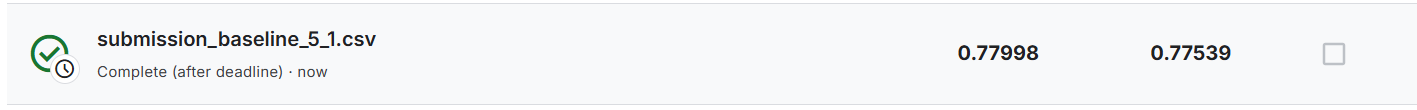

Добавление новых признаков, которые мы выводили в 3 гипотезы

In [ ]:
required_cols = ['amt_credit', 'amt_income_total', 'amt_annuity']
missing_cols = [col for col in required_cols if col not in common_cols]
if missing_cols:
    print(f"Предупреждение: Отсутствуют столбцы: {missing_cols}. Используем доступные.")
if 'amt_income_total' in common_cols and X_train_full['amt_income_total'].notna().any():
    X_train_full['credit_to_income'] = X_train_full['amt_credit'] / X_train_full['amt_income_total']
    df_test_processed['credit_to_income'] = df_test_processed['amt_credit'] / df_test_processed['amt_income_total']
if 'amt_annuity' in common_cols and 'amt_income_total' in common_cols and X_train_full['amt_income_total'].notna().any():
    X_train_full['annuity_to_income'] = X_train_full['amt_annuity'] / X_train_full['amt_income_total']
    df_test_processed['annuity_to_income'] = df_test_processed['amt_annuity'] / df_test_processed['amt_income_total']

X_train_full = X_train_full.fillna(0)
df_test_processed = df_test_processed.fillna(0)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)

In [ ]:
cat_model_optimal = CatBoostClassifier(
    iterations=1000,     
    learning_rate=0.03,       
    depth=7,          
    auto_class_weights='SqrtBalanced',
    random_state=42,
    l2_leaf_reg=2,  
    eval_metric='AUC',
    loss_function='Logloss',
    verbose=100)

cat_model_optimal.fit(X_train, y_train, eval_set=(X_val, y_val), cat_features=cat_cols)
cat_pred_val = cat_model_optimal.predict_proba(X_val)[:, 1]
cat_pred_test = cat_model_optimal.predict_proba(df_test_processed)[:, 1]

In [ ]:
def clean_column_names(df):
    df_clean = df.copy()
    df_clean.columns = [re.sub(r'[^a-zA-Z0-9_]', '_', col) for col in df.columns]
    return df_clean

X_train_clean = clean_column_names(X_train)
X_val_clean = clean_column_names(X_val)
df_test_processed_clean = clean_column_names(df_test_processed)

cat_cols_clean = [re.sub(r'[^a-zA-Z0-9_]', '_', col) for col in cat_cols]

In [ ]:
y_val_pred_proba  = 0.6 * cat_pred_val + 0.4 * lgb_pred_val

val_metrics = {
    'ROC-AUC': roc_auc_score(y_val, y_val_pred_proba),
    'Accuracy': accuracy_score(y_val, y_val_pred_proba > 0.5),
    'Precision': precision_score(y_val, y_val_pred_proba > 0.5),
    'Recall': recall_score(y_val, y_val_pred_proba > 0.5),
    'F1-Score': f1_score(y_val, y_val_pred_proba > 0.5)
}
for metric, value in val_metrics.items():
    print(f'Validation {metric}: {value:.4f}')

In [ ]:
test_pred_proba = cat_model_optimal.predict_proba(df_test_processed)[:, 1]
submission = pd.DataFrame({
    'sk_id_curr': df_test['sk_id_curr'],
    'target': test_pred_proba
})
submission.to_csv('submission_baseline_5_1.csv', index=False)

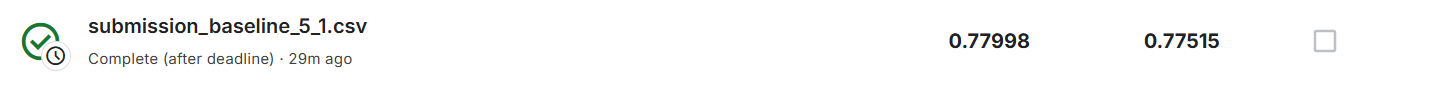